# Whisper

## Whisper fine-tuning on SEND audio to predict affective valence

In [1]:
import os
import pandas as pd
import numpy as np
from transformers import WhisperFeatureExtractor
from model_send_audio import preprocess_audio_data, load_audio_inputs, run_whisper

### 1. Preprocess audio inputs

#### Supplementary Table 8

Preprocess data from the Stanford Emotional Narratives Dataset (SEND). Data (not included in this repo) were collected and annotated as described in Ong et al. (2021), and were provided by Dr. Ong to be used in accordance with the end-user license agreement. The subset of the data with available video clips are preprocessed into audio inputs that can be used to fine-tune an audio-based model. Models are fine-tuned to predict the labels for affective valence in the SEND dataset averaged within 10-, 20-, and 30-second windows. The original splits for train, validation, and test sets in the Ong et al. paper are preserved here.

In [2]:
segment_duration_levels = [30, 20, 10]

In [3]:
data = {}
for segment_duration in segment_duration_levels:
    data[segment_duration] = preprocess_audio_data("data/raw/with-video/videos", "data/raw/ratings", 
                                                   segment_duration, sampling_rate=16000, 
                                                   splits=["train", "valid", "test"])

----------------------------------------------------------------------------------------------------
30-SECOND CLIPS
----------------------------------------------------------------------------------------------------
TRAIN SPLIT
Number of clips: 265

VALID SPLIT
Number of clips: 137

TEST SPLIT
Number of clips: 161

----------------------------------------------------------------------------------------------------
20-SECOND CLIPS
----------------------------------------------------------------------------------------------------
TRAIN SPLIT
Number of clips: 385

VALID SPLIT
Number of clips: 196

TEST SPLIT
Number of clips: 233

----------------------------------------------------------------------------------------------------
10-SECOND CLIPS
----------------------------------------------------------------------------------------------------
TRAIN SPLIT
Number of clips: 741

VALID SPLIT
Number of clips: 379

TEST SPLIT
Number of clips: 452



### 2. Specify training parameters

Input data are segmented over different time windows (10-, 20-, and 30-second segments). Hyperparameters tuned here are dropout levels.

In [4]:
model_name = "whisper-medium"
feature_extractor = WhisperFeatureExtractor.from_pretrained(f"openai/{model_name}")

n_epochs_levels = [50] 
conn_dropout_levels = [0, 0.1, 0.4]
actv_dropout_levels = [0, 0.1, 0.4]
attn_dropout_levels = [0, 0.1, 0.4]
constant_params = {"lr": 0.00005, 
                   "tune_layer": 23, 
                   "batch_size": 1, 
                   "warmup_steps": 500,
                   "device": "mps"}

### 3. Train models over a range of hyperparameters

In [5]:
from datasets import Dataset, Features, Value, Sequence

In [6]:
def load_audio_inputs(data, segment_duration, feature_extractor, 
                      splits=["train", "valid"]):
    
    print("-"*100 + f"\n{segment_duration}-SECOND CLIPS\n" + "-"*100)
    
    def process(examples):
        return feature_extractor(examples["audio"], sampling_rate=feature_extractor.sampling_rate, return_tensors="pt")
    
    def dict_list_generator(data_dict):
        num_examples = len(next(iter(data_dict.values())))
        for i in range(num_examples):
            yield {key: data_dict[key][i] for key in data_dict}
    
    features = Features({
        "id": Value("string"),
        "audio": Sequence(Value("float64")),
        "path": Value("string"),
        "label": Value("float64")
    })
    
    inputs = {}
    for split in splits:
        ds = Dataset.from_generator(dict_list_generator, 
                                    gen_kwargs={"data_dict": data[split]},
                                    features=features)
        inputs[split] = ds.map(process, batched=True)      
    
    print("\n" + "-"*100 + "\n")
    
    return inputs

In [7]:
validation = []

for segment_duration in segment_duration_levels:

    inputs = load_audio_inputs(data[segment_duration], segment_duration, feature_extractor, splits=["train", "valid"])

    for n_epochs in n_epochs_levels:
        for conn_dropout in conn_dropout_levels:
            for actv_dropout in actv_dropout_levels:
                for attn_dropout in attn_dropout_levels:
        
                    model_path, model_eval = run_whisper(model_name,
                                                         inputs,
                                                         segment_duration=segment_duration,
                                                         n_epochs=n_epochs,
                                                         conn_dropout=conn_dropout,
                                                         actv_dropout=actv_dropout, 
                                                         attn_dropout=attn_dropout,
                                                         **constant_params,
                                                         splits=["train", "valid"],
                                                         plot=False)
                    
                    validation += model_eval  
                    df = pd.DataFrame(validation)
                    df.to_csv(f"tables/{model_name}_validation.csv", index=False)

----------------------------------------------------------------------------------------------------
30-SECOND CLIPS
----------------------------------------------------------------------------------------------------


Map:   0%|          | 0/265 [00:00<?, ? examples/s]


----------------------------------------------------------------------------------------------------



Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at openai/whisper-medium and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



FOUND MODEL
Path: models/30s/whisper-medium/whisper-medium_30s_epochs50_lr5e-05_drop-conn0_drop-actv0_drop-attn0_tune23

EVALUATING MODEL


...

VALID   Mean: 0.48328   SD: 0.00874   RMSE: 0.22225   R: 0.06984 (p=0.17486)   CCC: 0.00541 (p=0.07500)

----------------------------------------------------------------------------------------------------



Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at openai/whisper-medium and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



FOUND MODEL
Path: models/10s/whisper-medium/whisper-medium_10s_epochs50_lr5e-05_drop-conn0.4_drop-actv0.4_drop-attn0.4_tune23

EVALUATING MODEL


TRAIN   Mean: 0.48845   SD: 0.00881   RMSE: 0.23886   R: 0.09755 (p=0.00788)   CCC: 0.00691 (p=0.00500)


VALID   Mean: 0.48618   SD: 0.00902   RMSE: 0.22185   R: 0.06709 (p=0.19249)   CCC: 0.00539 (p=0.09000)

----------------------------------------------------------------------------------------------------



### 4. Select model by validation set performance

In [8]:
valid_params = {}
for segment_duration in segment_duration_levels:
    
    segment_df = df[df["segment_duration"] == segment_duration]
    top_df = segment_df[segment_df["split"] == "valid"].sort_values("ccc", ascending=False)
    top_dict = top_df.to_dict(orient="records")[0]
    
    valid_params[segment_duration] = {"n_epochs": top_dict["n_epochs"],
                                      "conn_dropout": top_dict["conn_dropout"],
                                      "actv_dropout": top_dict["actv_dropout"],
                                      "attn_dropout": top_dict["attn_dropout"]}
    
    print("-"*100 + f"\nTOP MODELS FOR {segment_duration}-SECOND SEGMENTS")
    print(top_df[["n_epochs", "conn_dropout", "actv_dropout", "attn_dropout", "ccc", "ccc_p"]])
    print()

----------------------------------------------------------------------------------------------------
TOP MODELS FOR 30-SECOND SEGMENTS
    n_epochs  conn_dropout  actv_dropout  attn_dropout       ccc  ccc_p
5         50           0.0           0.0           0.4  0.601743  0.000
11        50           0.0           0.1           0.4  0.589486  0.000
13        50           0.0           0.4           0.0  0.567273  0.000
7         50           0.0           0.1           0.0  0.551470  0.000
15        50           0.0           0.4           0.1  0.542538  0.000
9         50           0.0           0.1           0.1  0.533203  0.000
3         50           0.0           0.0           0.1  0.532188  0.000
1         50           0.0           0.0           0.0  0.511140  0.000
17        50           0.0           0.4           0.4  0.268356  0.000
35        50           0.1           0.4           0.4  0.126050  0.006
33        50           0.1           0.4           0.1  0.108721  0.007
2

### 5. Evaluate model on the test set

#### Supplementary Tables 9-10

----------------------------------------------------------------------------------------------------
30-SECOND CLIPS
----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------



Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at openai/whisper-medium and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



FOUND MODEL
Path: models/30s/whisper-medium/whisper-medium_30s_epochs50_lr5e-05_drop-conn0_drop-actv0_drop-attn0.4_tune23

EVALUATING MODEL


TRAIN   Mean: 0.49332   SD: 0.23935   RMSE: 0.07277   R: 0.98943 (p=0.00000)   CCC: 0.95307 (p=0.00000)


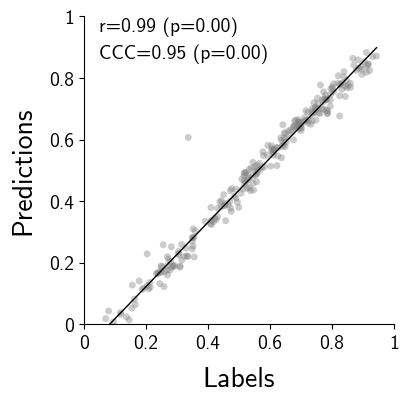

VALID   Mean: 0.51301   SD: 0.14977   RMSE: 0.16863   R: 0.64946 (p=0.00000)   CCC: 0.60174 (p=0.00000)


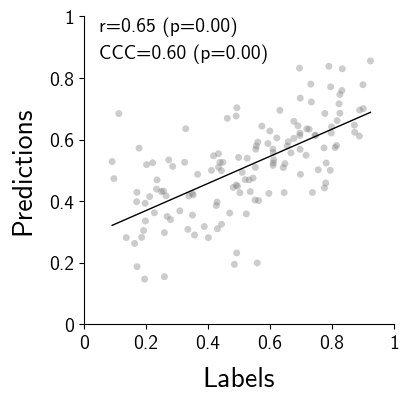

TEST    Mean: 0.52423   SD: 0.13117   RMSE: 0.16917   R: 0.64454 (p=0.00000)   CCC: 0.56531 (p=0.00000)


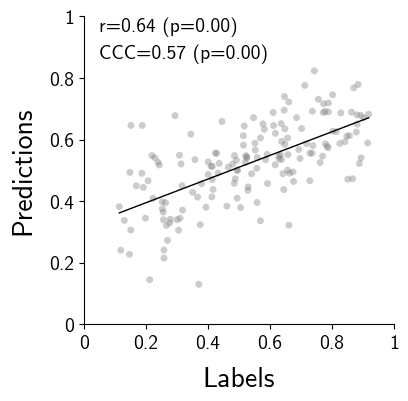


----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
20-SECOND CLIPS
----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------



Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at openai/whisper-medium and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



FOUND MODEL
Path: models/20s/whisper-medium/whisper-medium_20s_epochs50_lr5e-05_drop-conn0_drop-actv0.4_drop-attn0_tune23

EVALUATING MODEL


TRAIN   Mean: 0.48378   SD: 0.26129   RMSE: 0.09485   R: 0.97395 (p=0.00000)   CCC: 0.92856 (p=0.00000)


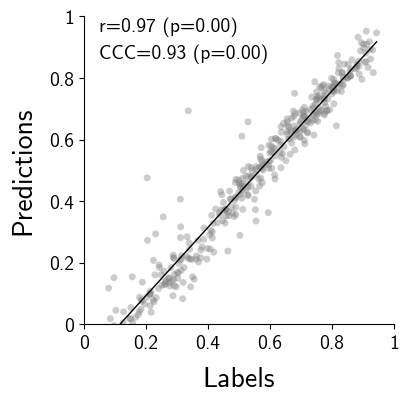

VALID   Mean: 0.50948   SD: 0.14806   RMSE: 0.18133   R: 0.57981 (p=0.00000)   CCC: 0.53527 (p=0.00000)


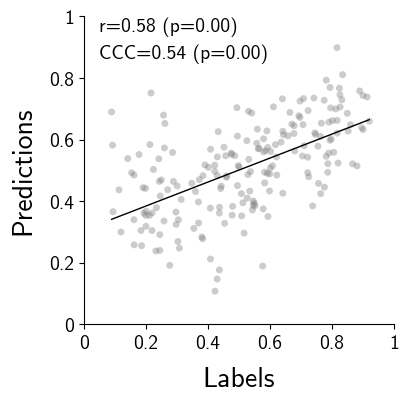

TEST    Mean: 0.51817   SD: 0.14428   RMSE: 0.19092   R: 0.51664 (p=0.00000)   CCC: 0.47230 (p=0.00000)


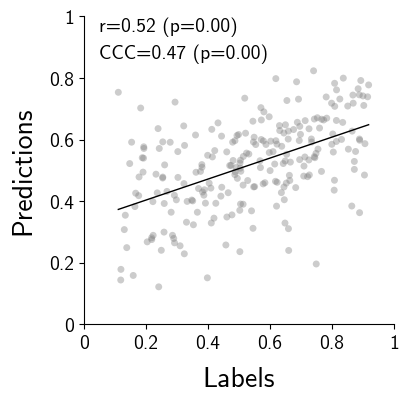


----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
10-SECOND CLIPS
----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------



Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at openai/whisper-medium and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



FOUND MODEL
Path: models/10s/whisper-medium/whisper-medium_10s_epochs50_lr5e-05_drop-conn0_drop-actv0_drop-attn0_tune23

EVALUATING MODEL


TRAIN   Mean: 0.55129   SD: 0.23127   RMSE: 0.00392   R: 0.99986 (p=0.00000)   CCC: 0.99986 (p=0.00000)


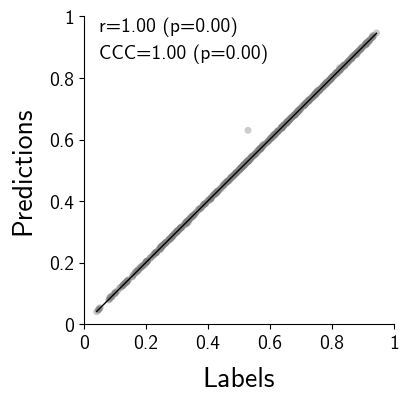

VALID   Mean: 0.57240   SD: 0.14067   RMSE: 0.21060   R: 0.43667 (p=0.00000)   CCC: 0.37885 (p=0.00000)


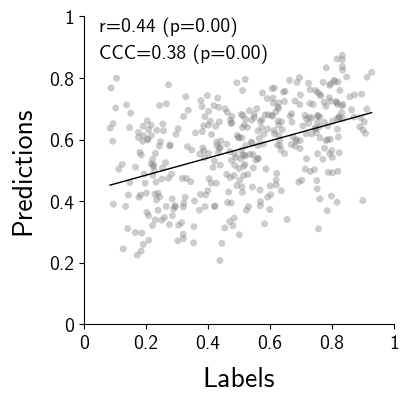

TEST    Mean: 0.57170   SD: 0.13896   RMSE: 0.20338   R: 0.44462 (p=0.00000)   CCC: 0.39454 (p=0.00000)


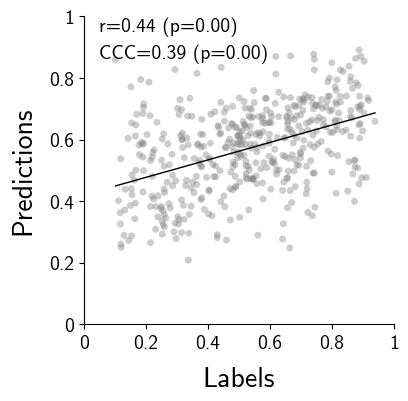


----------------------------------------------------------------------------------------------------



In [9]:
evaluation = []
for segment_duration in segment_duration_levels:
    
    inputs = load_audio_inputs(data[segment_duration], segment_duration, feature_extractor, 
                               splits=["train", "valid", "test"])
    
    model_path, model_eval = run_whisper(model_name, 
                                         inputs,
                                         segment_duration=segment_duration,
                                         n_epochs=valid_params[segment_duration]["n_epochs"],
                                         conn_dropout=valid_params[segment_duration]["conn_dropout"],
                                         actv_dropout=valid_params[segment_duration]["actv_dropout"],
                                         attn_dropout=valid_params[segment_duration]["attn_dropout"],
                                         **constant_params,
                                         splits=["train", "valid", "test"],
                                         plot=True)

    evaluation += model_eval

evaluation_df = pd.DataFrame(evaluation)
evaluation_df.to_csv(f"tables/{model_name}_evaluation.csv", index=False)